In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import re

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ARTIGOS SELECIONADOS/textos_pdfs.csv")
df.head()

,arquivo,texto,status
0,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 ...,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,ok
1,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 ...,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,ok
2,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 ...,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,ok
3,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 ...,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,ok
4,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 ...,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,ok


In [ ]:
df.shape # retorna o número de linhas e colunas

(800, 3)

# Pré-processamento do texto

In [ ]:
# Converter tudo para string
df["texto"] = df["texto"].astype(str)

In [ ]:
# Corrigir "hps" -> "https"
df["texto_limpo"] = df["texto"].str.replace("hps", "https", regex=False)

In [ ]:
# Remover quebras de linha \n e \\n
df["texto_limpo"] = (
    df["texto_limpo"]
    .str.replace("\n", " ", regex=False)
    .str.replace("\\n", " ", regex=False)
)

In [ ]:
# Remover caracteres não ASCII
df["texto_limpo"] = (
    df["texto_limpo"]
    .apply(lambda x: x.encode("ascii", "ignore").decode())
)

In [ ]:
# Transformar para minúsculas
df["texto_limpo"] = df["texto_limpo"].str.lower()

In [ ]:
# Remover pontuação indesejada (mantendo / . :)
df["texto_limpo"] = df["texto_limpo"].str.replace(r"[^\w\s:/\.]", " ", regex=True)

In [ ]:
# Remover múltiplos espaços
df["texto_limpo"] = df["texto_limpo"].str.replace(r"\s+", " ", regex=True).str.strip()

In [ ]:
df[["texto", "texto_limpo"]].head()

,texto,texto_limpo
0,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,. . latest updates: https://dl.acm.org/doi/10....
1,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,. . latest updates: https://dl.acm.org/doi/10....
2,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,. . latest updates: https://dl.acm.org/doi/10....
3,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,. . latest updates: https://dl.acm.org/doi/10....
4,.\n.\nLatest updates: hps://dl.acm.org/doi/10...,. . latest updates: https://dl.acm.org/doi/10....


In [ ]:
def remover_lixo_academico(texto):
    padroes = [
        r'latest updates',
        r'https?://\S+',
        r'doi',
        r'research article'
    ]

    for p in padroes:
        texto = re.sub(p, '', texto)

    return texto

df["texto_limpo"] = df["texto_limpo"].apply(remover_lixo_academico)

In [ ]:
# =========================
# 0. IMPORTS
# =========================
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# =========================
# 1. LIMPEZA AVANÇADA
# =========================

def limpeza_artigo(texto):
    texto = str(texto).lower()

    # remover URLs
    texto = re.sub(r'h\S*ps\S+', '', texto)
    texto = re.sub(r'http\S+|www\S+', '', texto)

    # remover DOI
    texto = re.sub(r'doi\s*\S+', '', texto)

    # remover padrões ACM
    padroes = [
        "latest updates", "research article",
        "acm", "pdf download", "total citations",
        "published", "open access",
        "support provided", "all rights reserved"
    ]

    for p in padroes:
        texto = re.sub(p, '', texto)

    # remover universidades e institutos
    texto = re.sub(r'.*university.*', '', texto)
    texto = re.sub(r'.*institute.*', '', texto)

    # remover países
    paises = [
        "china", "united states", "usa", "uk",
        "france", "germany", "italy", "canada"
    ]
    for p in paises:
        texto = re.sub(r'\b' + p + r'\b', '', texto)

    # remover números
    texto = re.sub(r'\b\d+\b', '', texto)

    # remover caracteres especiais
    texto = re.sub(r'[^\w\s]', ' ', texto)

    # remover linhas muito curtas
    linhas = texto.split('\n')
    linhas = [l for l in linhas if len(l.strip()) > 30]
    texto = ' '.join(linhas)

    # normalização final
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

df["texto_limpo"] = df["texto"].apply(limpeza_artigo)

In [ ]:
# =========================
# 2. EXTRAÇÃO DO CONTEÚDO PRINCIPAL
# =========================

def extrair_inicio(texto, max_palavras=200):
    palavras = texto.split()
    return ' '.join(palavras[:max_palavras])

df["texto_final"] = df["texto_limpo"].apply(extrair_inicio)

# remover textos ruins
df = df[df["texto_final"].str.len() > 100]

# TOP WORDS

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
stop_pt = set(stopwords.words('portuguese'))
stop_en = set(stopwords.words('english'))

stopwords_total = stop_pt.union(stop_en)

print("Stopwords carregadas:", len(stopwords_total))

Stopwords carregadas: 398


In [ ]:
texto_total = " ".join(df["texto_limpo"].astype(str).tolist())

In [ ]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(texto_total)
len(tokens)

7395375

In [ ]:
tokens_filtrados = [
    t for t in tokens
    if t.isalpha() and t not in stopwords_total and len(t) > 2
]

len(tokens_filtrados)

4673936

In [ ]:
from collections import Counter

contador = Counter(tokens_filtrados)
top_30 = contador.most_common(30)

top_30

[('data', 26191),
 ('based', 22580),
 ('article', 19684),
 ('vol', 19039),
 ('model', 18939),
 ('learning', 17670),
 ('time', 12855),
 ('using', 12385),
 ('publicationdate', 11761),
 ('computing', 11127),
 ('models', 10757),
 ('also', 10667),
 ('transactions', 10617),
 ('different', 10506),
 ('two', 10398),
 ('information', 10359),
 ('used', 10100),
 ('proceedings', 9938),
 ('methods', 9274),
 ('however', 9192),
 ('trans', 9141),
 ('one', 8830),
 ('network', 8709),
 ('research', 8653),
 ('use', 8598),
 ('systems', 8497),
 ('method', 8381),
 ('students', 8288),
 ('work', 8279),
 ('first', 8106)]

In [ ]:
df_top = pd.DataFrame(top_30, columns=["palavra", "frequência"])
df_top

,palavra,frequência
0,data,26191
1,based,22580
2,article,19684
3,vol,19039
4,model,18939
5,learning,17670
6,time,12855
7,using,12385
8,publicationdate,11761
9,computing,11127


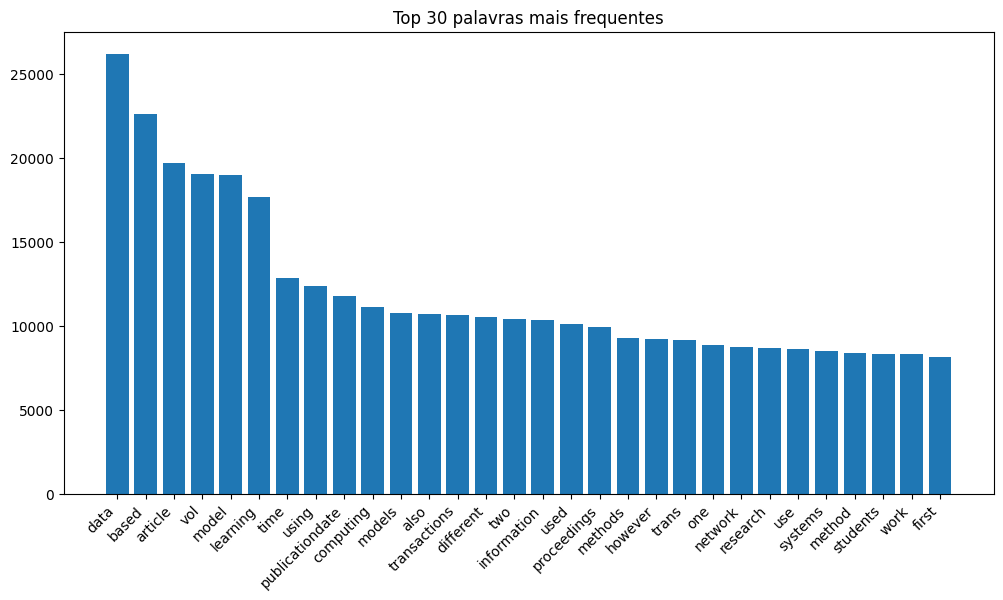

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(df_top["palavra"], df_top["frequência"])
plt.xticks(rotation=45, ha='right')
plt.title("Top 30 palavras mais frequentes")
plt.show()

# TOP KEY WORDS

In [ ]:
import re
from collections import Counter

todas_keywords = []

padrao = re.compile(
    r'(key\s*words?|keywords?|key\s*words\s*and\s*phrases|index\s*terms)\s*[:\-]\s*(.+)',
    re.IGNORECASE
)

for texto in df["texto"]:

    match = padrao.search(texto)

    if match:
        linha_keywords = match.group(2)

        # remover quebra de linha
        linha_keywords = linha_keywords.replace("\n", " ")

        # separar keywords
        kws = re.split(r',|;', linha_keywords)

        for kw in kws:
            kw = kw.strip().lower()

            if kw:
                todas_keywords.append(kw)

frequencia = Counter(todas_keywords)

print(frequencia.most_common(20))

[('deep learning', 25), ('machine learning', 19), ('privacy', 14), ('blockchain', 14), ('federated learning', 13), ('covid-19', 13), ('security', 12), ('recommender systems', 10), ('deeplearning', 9), ('internet of things', 8), ('computer science education', 8), ('large language models', 7), ('neural networks', 7), ('representation learning', 6), ('softwaretesting', 6), ('reinforcement learning', 5), ('artificial intelligence', 5), ('fairness', 5), ('graph neural networks', 5), ('contrastive learning', 5)]


In [ ]:
import re
from collections import Counter, defaultdict

contador = Counter()
forma_original = {}

for kw in todas_keywords:

    kw_limpa = kw.lower().strip()

    # chave normalizada (remove espaços e hífens)
    chave = re.sub(r'[\s\-]', '', kw_limpa)

    contador[chave] += 1

    # salva a primeira forma encontrada
    if chave not in forma_original:
        forma_original[chave] = kw_limpa

# reconstruir resultado com forma original
resultado = [(forma_original[k], v) for k, v in contador.most_common(20)]

print(resultado)

[('deep learning', 34), ('machine learning', 25), ('federated learning', 20), ('privacy', 14), ('blockchain', 14), ('covid-19', 13), ('recommender systems', 12), ('security', 12), ('software  testing', 12), ('neural networks', 11), ('internet of things', 11), ('largelanguage models', 9), ('computer science education', 9), ('edge computing', 8), ('representation learning', 7), ('computational thinking', 7), ('computing education', 7), ('reinforcement learning', 6), ('graph neural networks', 6), ('contrastive learning', 6)]


In [ ]:
# converter para dataframe
df_key_words = pd.DataFrame(resultado, columns=['Keyword', 'Frequencia'])
df_key_words

,Keyword,Frequencia
0,deep learning,34
1,machine learning,25
2,federated learning,20
3,privacy,14
4,blockchain,14
5,covid-19,13
6,recommender systems,12
7,security,12
8,software testing,12
9,neural networks,11


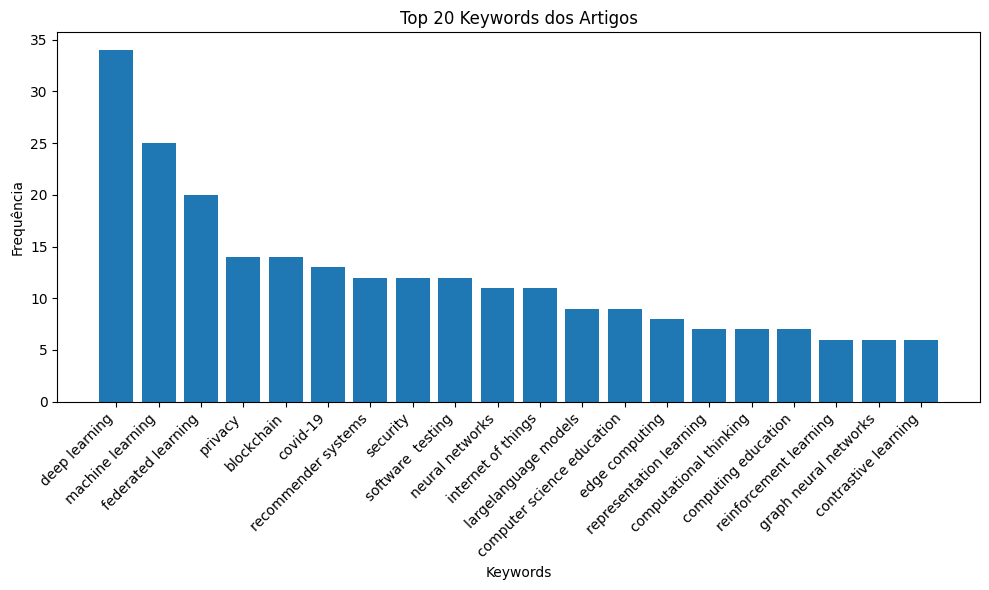

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(df_key_words['Keyword'], df_key_words['Frequencia'])

plt.xticks(rotation=45, ha='right')
plt.xlabel("Keywords")
plt.ylabel("Frequência")
plt.title("Top 20 Keywords dos Artigos")

plt.tight_layout()
plt.show()

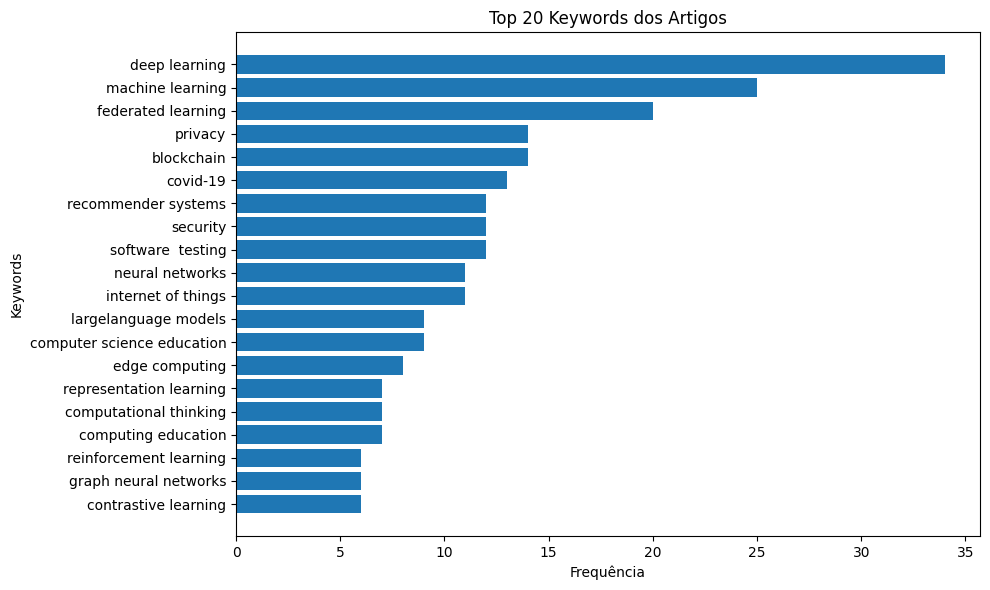

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(df_key_words['Keyword'], df_key_words['Frequencia'])

plt.xlabel("Frequência")
plt.ylabel("Keywords")
plt.title("Top 20 Keywords dos Artigos")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Top N-grams (bigram e trigram) do corpus

Para identificar padrões de escrita no corpus, uma técnica muito usada em Natural Language Processing e Corpus Linguistics é a extração de n-grams, que são sequências de palavras consecutivas no texto.

- Bigram → sequência de 2 palavras

- Trigram → sequência de 3 palavras

Isso permite descobrir padrões típicos da escrita acadêmica como:

> in this paper

> as a result

> on the other

> deep learning model

In [ ]:
import re
from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords, words
import nltk

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))
english_words = set(words.words())

ruido_editorial = {
    'article', 'vol', 'volume', 'issue', 'publication', 'publicationdate',
    'date', 'copyright', 'doi', 'proceedings', 'conference',
    'acmcomput', 'andsystems', 'methodol', 'onspatialalgorithms',
    'acmtransactions', 'acmtrans'
}

ruido_pdf = {
    'circle', 'gid', 'prime', 'bracehext', 'check'
}

ruido_metricas = {
    'download', 'downloads', 'citations', 'total', 'support', 'provided'
}

# NOVOS RUÍDOS IDENTIFICADOS
ruido_acm = {
    'permission', 'digital', 'hard', 'copies', 'profit', 'commercial',
    'advantage', 'bear', 'notice', 'distributed', 'citation', 'format',
    'copyrights', 'page'
}

ruido_locais = {
    'york', 'usa', 'ny'
}

ruido_figuras = {
    'figure', 'fig', 'shown', 'graph', 'december'
}

bigram_counter = Counter()
trigram_counter = Counter()

for texto in df["texto"]:

    texto = texto.lower()

    # remover urls
    texto = re.sub(r'http\S+', ' ', texto)

    # remover números
    texto = re.sub(r'\d+', ' ', texto)

    tokens = re.findall(r'\b[a-z]+\b', texto)

    tokens = [
        t for t in tokens
        if t not in stop_words
        and t not in ruido_editorial
        and t not in ruido_pdf
        and t not in ruido_metricas
        and t not in ruido_acm
        and t not in ruido_locais
        and t not in ruido_figuras
        and len(t) > 2
        and (t in english_words or len(t) > 6)
    ]

    bigram_counter.update(ngrams(tokens, 2))

print("Top Bigrams")
for bg, freq in bigram_counter.most_common(20):
    print(" ".join(bg), freq)

Top Bigrams
computer science 3572
computing education 2901
software engineering 2175
deep learning 2160
machine learning 2113
transactions computing 1790
computer vision 1632
neural networks 1595
real world 1515
real time 1449
neural network 1351
artificial intelligence 1285
state art 1240
large scale 1054
natural language 1042
pattern recognition 1041
science education 1019
federated learning 977
science technology 895
ground truth 858


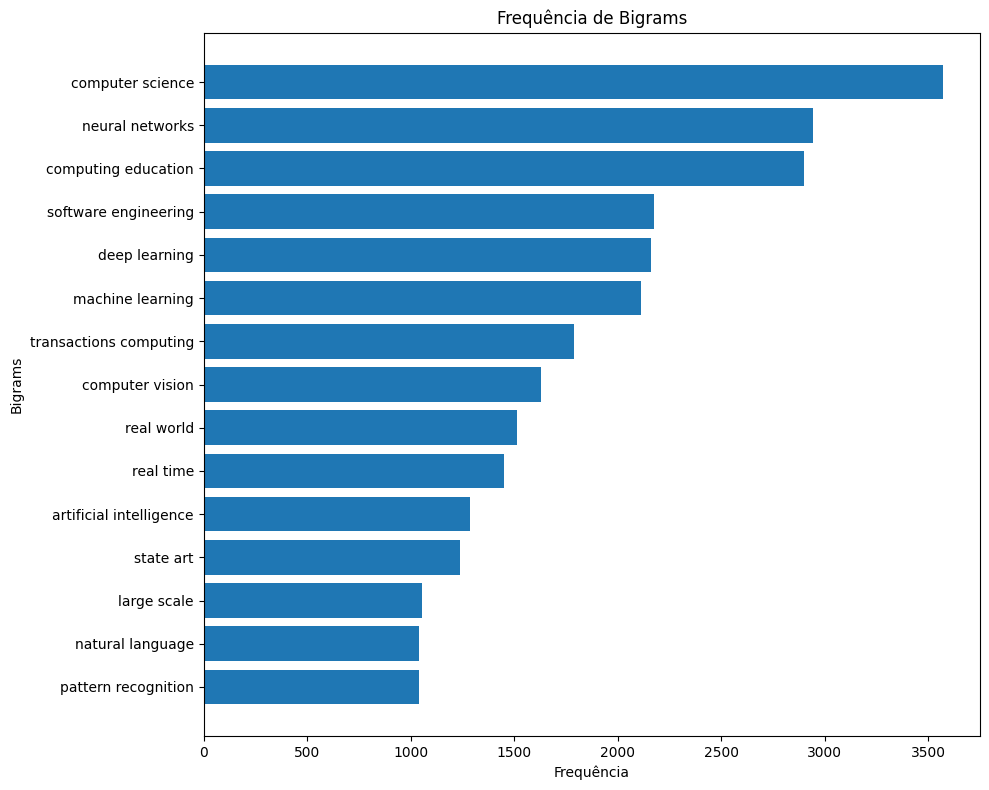

In [ ]:
# Dados como dicionário
bigrams = {
    "computer science": 3572,
    "neural networks": 2946,
    "computing education": 2901,
    "software engineering": 2175,
    "deep learning": 2160,
    "machine learning": 2113,
    "transactions computing": 1790,
    "computer vision": 1632,
    "real world": 1515,
    "real time": 1449,
    "artificial intelligence": 1285,
    "state art": 1240,
    "large scale": 1054,
    "natural language": 1042,
    "pattern recognition": 1041
}

# Separando chaves e valores
labels = list(bigrams.keys())
values = list(bigrams.values())

# Criando gráfico de barras horizontal
plt.figure(figsize=(10, 8))
plt.barh(labels, values)

# Inverter eixo para o maior ficar no topo
plt.gca().invert_yaxis()

# Títulos
plt.title("Frequência de Bigrams")
plt.xlabel("Frequência")
plt.ylabel("Bigrams")

plt.tight_layout()
plt.show()

In [ ]:
import re
from collections import Counter

padroes = {
    "abstract": r"\babstract\b",
    "introduction": r"\bintroduction\b",
    "related reviews": r"\brelated reviews\b",
    "related work": r"\brelated work\b",
    "background": r"\bbackground\b",
    "methods": r"\bmethod(s|ology)?\b",
    "results": r"\bresults?\b",
    "discussion": r"\bdiscussion\b",
    "conclusion": r"\bconclusions?\b"
}

contador_secoes = Counter()

for texto in df["texto_limpo"]:
    for nome, padrao in padroes.items():
        ocorrencias = len(re.findall(padrao, texto))
        contador_secoes[nome] += ocorrencias

print(contador_secoes)

Counter({'methods': 19100, 'results': 10435, 'background': 1006, 'discussion': 767, 'abstract': 655, 'introduction': 465, 'conclusion': 459, 'related work': 226, 'related reviews': 10})


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Criar o vetorizador
vectorizer = TfidfVectorizer(
    max_features=1000,       # limita as palavras mais relevantes
    ngram_range=(1,2),       # unigramas + bigramas (IMPORTANTE!)
    min_df=2,                # ignora termos raros
    max_df=0.8               # ignora termos muito frequentes (ruído)
)

# 2. Ajustar e transformar os textos
X_tfidf = vectorizer.fit_transform(df["texto_limpo"])

# 3. Ver formato da matriz
print(X_tfidf.shape)

(800, 1000)


In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# =========================
# 1. STOPWORDS
# =========================

stopwords_pt = stopwords.words('portuguese')
stopwords_en = stopwords.words('english')

stopwords_extra = [
    "publication", "publicationdate", "date",
    "proceedings", "ieee", "article",
    "vol", "pp", "doi",
    "copyright", "conference",
    "journal", "issue",
    "paper", "research",
    "et", "al",
    "figure", "table",
    "using", "based", "used"
]

todas_stopwords = list(set(stopwords_pt + stopwords_en + stopwords_extra))

# =========================
# 2. FUNÇÃO DE LIMPEZA
# =========================

def limpar_texto(texto):
    texto = texto.lower()

    # remover números
    texto = re.sub(r'\b\d+\b', '', texto)

    # remover caracteres especiais
    texto = re.sub(r'[^\w\s]', ' ', texto)

    # remover espaços extras
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# aplicar limpeza
df["texto_limpo"] = df["texto_limpo"].apply(limpar_texto)

# =========================
# 3. TF-IDF
# =========================

vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2),   # unigramas + bigramas
    min_df=2,
    max_df=0.6,          # reduz termos muito frequentes
    stop_words=todas_stopwords
)

X_tfidf = vectorizer.fit_transform(df["texto_limpo"])

# =========================
# 4. ANÁLISE GLOBAL
# =========================

media_tfidf = np.mean(X_tfidf.toarray(), axis=0)
termos = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame({
    "termo": termos,
    "score": media_tfidf
}).sort_values(by="score", ascending=False)

print("\nTOP 20 TERMOS (TF-IDF):\n")
print(df_tfidf.head(20))



TOP 20 TERMOS (TF-IDF):

           termo     score
422        image  0.047188
852     students  0.041053
270    education  0.032775
391        graph  0.031953
945         user  0.030161
136         code  0.029313
234    detection  0.029211
423       images  0.028451
820     software  0.026677
963        video  0.025395
831      spatial  0.024668
156       comput  0.024064
1             3d  0.023640
671      privacy  0.023162
157  comput surv  0.021902
864         surv  0.021817
946        users  0.020603
774     security  0.020535
886     temporal  0.020365
265         edge  0.020236


#BERT

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

textos = df["texto_limpo"].tolist()

embeddings = model.encode(textos, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

In [ ]:
from sklearn.cluster import KMeans

k = 5  # você pode testar 3–10
kmeans = KMeans(n_clusters=k, random_state=42)

df["cluster"] = kmeans.fit_predict(embeddings)

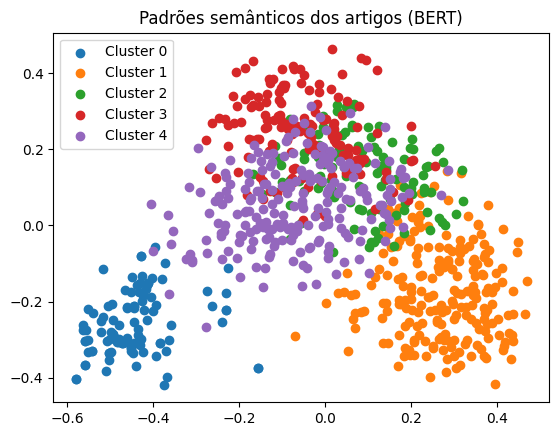

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for i in range(k):
    pontos = embeddings_2d[df["cluster"] == i]
    plt.scatter(pontos[:, 0], pontos[:, 1], label=f'Cluster {i}')

plt.legend()
plt.title("Padrões semânticos dos artigos (BERT)")
plt.show()

In [ ]:
for cluster_id in range(k):
    print(f"\n=== CLUSTER {cluster_id} ===")

    exemplos = df[df["cluster"] == cluster_id].head(5)

    for i, row in exemplos.iterrows():
        print(f"\nDoc {i}:")
        print(row["texto_limpo"][:300])


=== CLUSTER 0 ===

Doc 215:
the landscape of user centered misinformation interventions a systematic literature review computing surveys volume issue november the landscape of user centered misinformation interventions a systematic literature review misinformationisoneofthekeychallengesfacingsocietytoday user centeredmisinform

Doc 266:
deceived by immersion a systematic analysis of deceptive design in extended reality deceptive design in games and xr usable privacy and security lydia choong david r cheriton school of computer science david r cheriton school of computer science computing surveys volume issue october deceived by imm

Doc 295:
voices of elementary computer science teachers computer science integration rationales and practices michael karlin csu dominguez hills carson ca transactions on computing education volume issue december voices of elementary computer science teachers computer science integration rationales and pract

Doc 298:
recruiting practices in informal cs le

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# stopwords padrão
stop_en = stopwords.words('english')

# stopwords extras (ESSENCIAL pro seu caso)
stop_extra = [
    "et", "al", "using", "based", "paper",

    "transactions", "volume", "december", "cs", "black",

    "study", "research",
    "method", "methods",
    "issue", "article", "however"
]

todas_stopwords = list(set(stop_en + stop_extra))


for cluster_id in range(k):
    print(f"\n=== PADRÕES DO CLUSTER {cluster_id} ===")

    textos_cluster = df[df["cluster"] == cluster_id]["texto_final"]

    vectorizer = TfidfVectorizer(
        max_features=15,
        stop_words=todas_stopwords,
        ngram_range=(1,2),   # 🔥 importante!
        min_df=2
    )

    X = vectorizer.fit_transform(textos_cluster)

    termos = vectorizer.get_feature_names_out()

    print(termos)


=== PADRÕES DO CLUSTER 0 ===
['computer' 'computer science' 'computing' 'computing education'
 'development' 'education' 'learning' 'professional' 'programming'
 'school' 'science' 'skills' 'social' 'students' 'teachers']

=== PADRÕES DO CLUSTER 1 ===
['3d' 'applications' 'computing' 'data' 'features' 'graphics'
 'graphics tog' 'image' 'images' 'information' 'key' 'learning'
 'multimedia' 'tog' 'video']

=== PADRÕES DO CLUSTER 2 ===
['algorithms' 'algorithms systems' 'computing' 'data' 'graph'
 'information' 'learning' 'model' 'prediction' 'real' 'spatial'
 'spatial algorithms' 'systems' 'temporal' 'time']

=== PADRÕES DO CLUSTER 3 ===
['computing' 'data' 'edge' 'federated' 'information' 'internet'
 'internet technology' 'iot' 'key' 'learning' 'network' 'privacy'
 'security' 'systems' 'technology']

=== PADRÕES DO CLUSTER 4 ===
['code' 'computing' 'data' 'engineering' 'key' 'language' 'learning'
 'machine' 'model' 'models' 'software' 'systems' 'technology' 'testing'
 'ware']


In [ ]:
import re
import numpy as np
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

conectores = [
    "however", "therefore", "moreover", "thus", "consequently",
    "in addition", "on the other hand", "for example", "for instance",
    "as a result", "in contrast", "furthermore", "meanwhile"
]

marcadores_academicos = [
    "this paper", "this study", "we propose", "we present",
    "we evaluate", "we investigate", "results show",
    "in this section", "our results", "in conclusion"
]

def extrair_features_estilo(texto):
    texto = str(texto).lower()
    sentencas = sent_tokenize(texto) if len(texto) > 0 else []
    palavras = re.findall(r"\b[a-z]+\b", texto)

    if len(sentencas) == 0:
        sentencas = [texto]

    n_palavras = len(palavras)
    n_sentencas = len(sentencas)
    vocab_unico = len(set(palavras))
    ttr = vocab_unico / n_palavras if n_palavras else 0

    tam_medio_frase = n_palavras / n_sentencas if n_sentencas else 0
    palavras_por_paragrafo = len(texto.split("\n")) if "\n" in texto else 1

    conectores_count = sum(texto.count(c) for c in conectores)
    academico_count = sum(texto.count(m) for m in marcadores_academicos)

    passiva = len(re.findall(r"\b(is|are|was|were|be|been|being)\b\s+\w+ed\b", texto))
    pontuacao = len(re.findall(r"[,:;().\-]", texto))

    return pd.Series({
        "n_palavras": n_palavras,
        "n_sentencas": n_sentencas,
        "tam_medio_frase": tam_medio_frase,
        "vocab_unico": vocab_unico,
        "ttr": ttr,
        "conectores": conectores_count,
        "marcadores_academicos": academico_count,
        "voz_passiva": passiva,
        "pontuacao": pontuacao,
    })

df_features = df["texto_limpo"].apply(extrair_features_estilo)
df = pd.concat([df, df_features], axis=1)

cols = [
    "n_palavras", "n_sentencas", "tam_medio_frase",
    "vocab_unico", "ttr", "conectores",
    "marcadores_academicos", "voz_passiva", "pontuacao"
]

X = StandardScaler().fit_transform(df[cols])

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster_estilo"] = kmeans.fit_predict(X)

print(df.groupby("cluster_estilo")[cols].mean().round(2))

                n_palavras  n_palavras  n_sentencas  n_sentencas  \
cluster_estilo                                                     
0                  3601.22     3601.22          1.0          1.0   
1                  9133.17     9133.17          1.0          1.0   
2                  9078.62     9078.62          1.0          1.0   
3                 19061.75    19061.75          1.0          1.0   
4                 14163.23    14163.23          1.0          1.0   

                tam_medio_frase  tam_medio_frase  vocab_unico  vocab_unico  \
cluster_estilo                                                               
0                       3601.22          3601.22      1160.81      1160.81   
1                       9133.17          9133.17      2414.30      2414.30   
2                       9078.62          9078.62      2141.82      2141.82   
3                      19061.75         19061.75      3198.39      3198.39   
4                      14163.23         14163.23      4

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Shape de entrada: (800, 10)
Colunas de entrada: ['n_palavras', 'n_sentencas', 'tam_medio_frase', 'vocab_unico', 'ttr', 'repeticao', 'conectores', 'marcadores_academicos', 'voz_passiva', 'pontuacao']

=== RESUMO GERAL DAS FEATURES ===

                       count      mean       std      min       25%       50%  \
n_palavras             800.0  5752.114  3128.362  325.000  3349.500  5492.500   
n_sentencas            800.0   964.388   639.334   23.000   497.000   920.000   
tam_medio_frase        800.0     6.723     2.062    0.900     5.589     6.484   
vocab_unico            800.0  2186.059  1075.602  210.000  1338.250  2157.500   
ttr                    800.0     0.403     0.084    0.179     0.342     0.416   
repeticao              800.0     0.597     0.084    0.285     0.540     0.584   
conectores             800.0    69.796    43.430    0.000    36.000    64.000   
marcadores_academicos  800.0    14.552    10.541    0.000     7.000    12.000   
voz_passiva            800.0    71.2

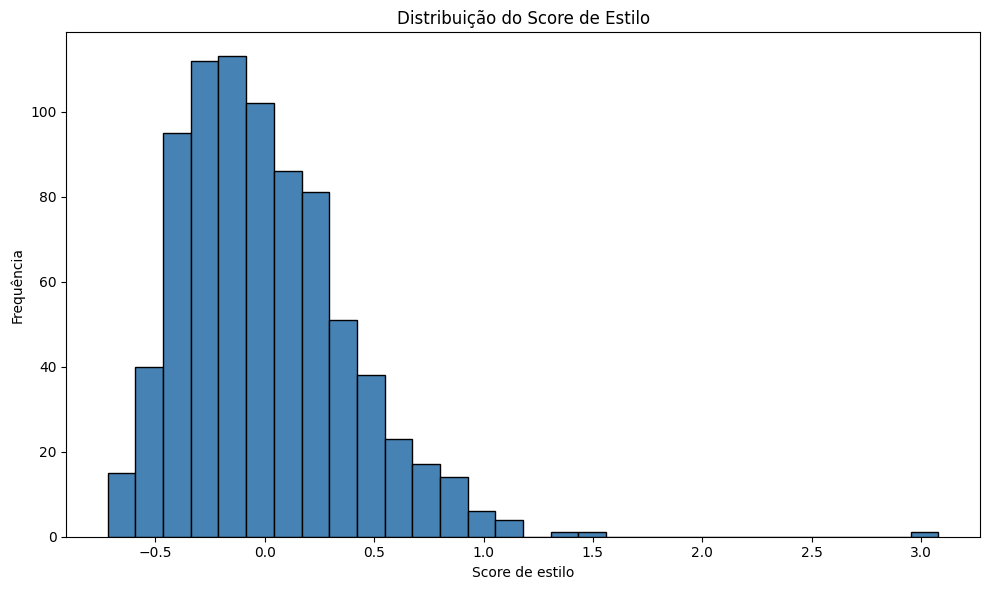

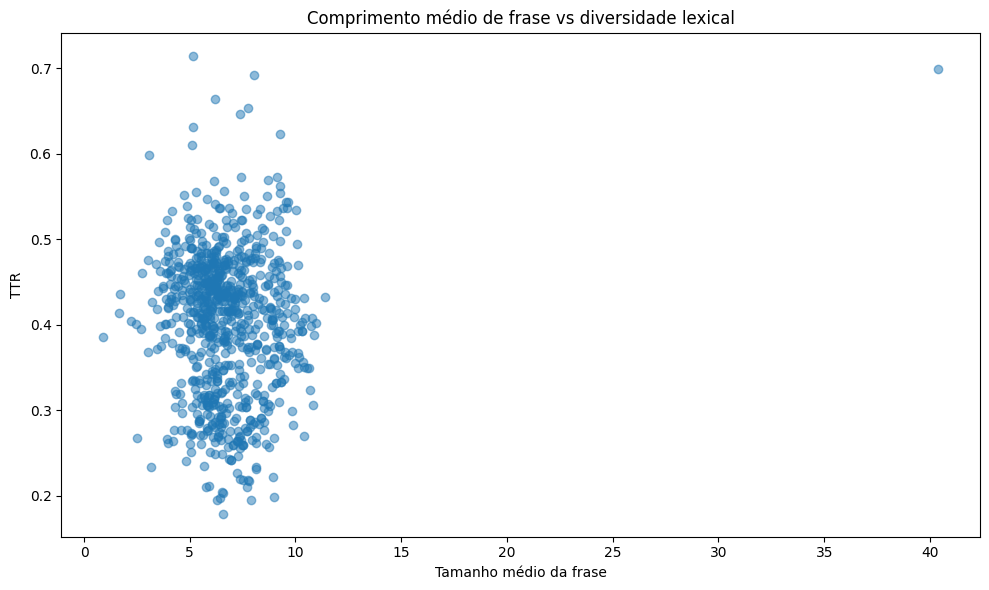

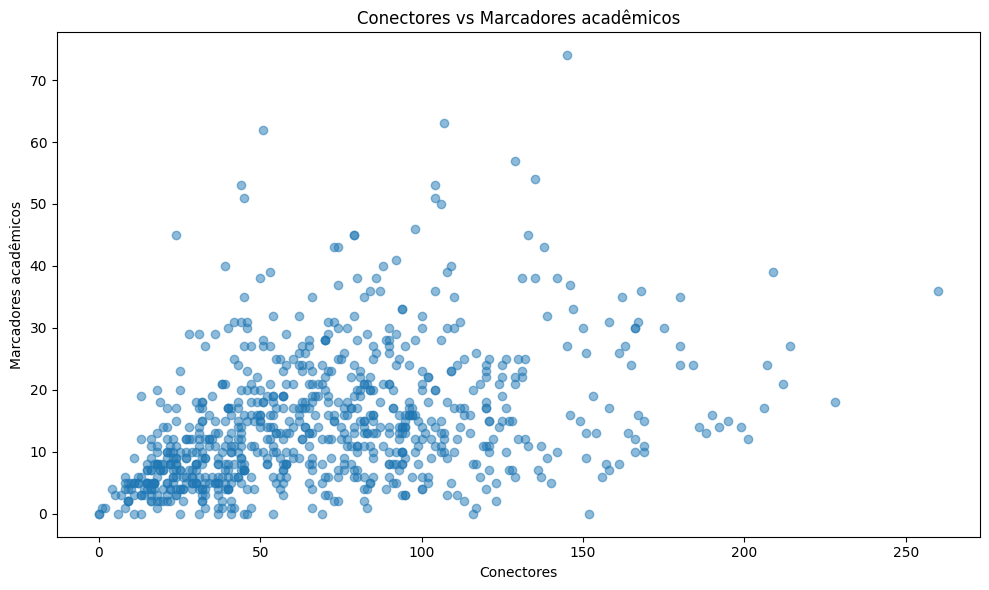

In [ ]:
import re
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.preprocessing import StandardScaler

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# =========================================================
# 0. CARREGAR BASE ORIGINAL
# =========================================================
# Ajuste o caminho se necessário
df = pd.read_csv("/content/drive/MyDrive/ARTIGOS SELECIONADOS/textos_pdfs.csv")

# manter só as colunas originais necessárias
df = df[["arquivo", "texto", "status"]].copy()

# =========================================================
# 1. STOPWORDS
# =========================================================
stop_pt = set(stopwords.words("portuguese"))
stop_en = set(stopwords.words("english"))
stopwords_total = stop_pt.union(stop_en)

stop_extra = {
    "article", "paper", "study", "research", "using", "based", "results",
    "method", "methods", "conclusion", "introduction", "abstract",
    "figure", "table", "data", "model", "models", "system", "systems",
    "et", "al", "doi", "vol", "volume", "issue", "pp", "acm", "ieee",
    "copyright", "proceedings", "conference", "journal", "https", "http"
}
stopwords_total = stopwords_total.union(stop_extra)

# =========================================================
# 2. LIMPEZA BÁSICA
# =========================================================
def limpar_texto_base(texto):
    texto = str(texto).lower()
    texto = texto.replace("hps", "https")
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"\d+", " ", texto)
    texto = re.sub(r"[^\w\s\.\!\?\:\;\,]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["texto_estilo"] = df["texto"].apply(limpar_texto_base)

# =========================================================
# 3. FUNÇÕES DE ESTILO
# =========================================================
conectores = [
    "however", "therefore", "moreover", "thus", "consequently",
    "in addition", "on the other hand", "for example", "for instance",
    "as a result", "in contrast", "furthermore", "meanwhile",
    "although", "because", "while", "since", "hence"
]

marcadores_academicos = [
    "this paper", "this study", "we propose", "we present",
    "we evaluate", "we investigate", "we analyze",
    "results show", "in this section", "our results", "we found",
    "we discuss", "in conclusion", "the proposed", "the results"
]

def voz_passiva(texto):
    padrao = r"\b(is|are|was|were|be|been|being)\b\s+\w+(ed|en)\b"
    return len(re.findall(padrao, texto))

def contar_conectores(texto):
    texto = texto.lower()
    return sum(texto.count(c) for c in conectores)

def contar_marcadores(texto):
    texto = texto.lower()
    return sum(texto.count(m) for m in marcadores_academicos)

def features_estilo(texto):
    texto = str(texto).lower()
    sentencas = sent_tokenize(texto) if texto.strip() else []
    palavras = word_tokenize(texto)

    palavras = [
        p for p in palavras
        if p.isalpha() and p not in stopwords_total and len(p) > 2
    ]

    n_palavras = len(palavras)
    n_sentencas = len(sentencas) if len(sentencas) > 0 else 1
    vocab_unico = len(set(palavras))
    ttr = vocab_unico / n_palavras if n_palavras > 0 else 0
    tam_medio_frase = n_palavras / n_sentencas if n_sentencas > 0 else 0
    repeticao = 1 - ttr if n_palavras > 0 else 0
    pontuacao = len(re.findall(r"[,:;().\-]", texto))

    return pd.Series({
        "n_palavras": n_palavras,
        "n_sentencas": n_sentencas,
        "tam_medio_frase": tam_medio_frase,
        "vocab_unico": vocab_unico,
        "ttr": ttr,
        "repeticao": repeticao,
        "conectores": contar_conectores(texto),
        "marcadores_academicos": contar_marcadores(texto),
        "voz_passiva": voz_passiva(texto),
        "pontuacao": pontuacao
    })

# =========================================================
# 4. APLICAR FEATURES
# =========================================================
df_features = df["texto_estilo"].apply(features_estilo)
df = pd.concat([df, df_features], axis=1)

# remover qualquer coluna duplicada por segurança
df = df.loc[:, ~df.columns.duplicated()].copy()

# =========================================================
# 5. NORMALIZAÇÃO E SCORE FINAL
# =========================================================
cols_estilo = [
    "n_palavras", "n_sentencas", "tam_medio_frase",
    "vocab_unico", "ttr", "repeticao",
    "conectores", "marcadores_academicos", "voz_passiva", "pontuacao"
]

X_base = df.loc[:, cols_estilo].copy()

print("Shape de entrada:", X_base.shape)
print("Colunas de entrada:", X_base.columns.tolist())

scaler = StandardScaler()
X_estilo = scaler.fit_transform(X_base)

df_estilo_norm = pd.DataFrame(
    X_estilo,
    columns=[f"{c}_norm" for c in cols_estilo],
    index=df.index
)

df = pd.concat([df, df_estilo_norm], axis=1)

df["score_estilo"] = (
    df["tam_medio_frase_norm"] * 0.20 +
    df["ttr_norm"] * 0.15 +
    df["conectores_norm"] * 0.20 +
    df["marcadores_academicos_norm"] * 0.20 +
    df["voz_passiva_norm"] * 0.10 +
    df["pontuacao_norm"] * 0.10 -
    df["repeticao_norm"] * 0.05
)

# =========================================================
# 6. RESULTADOS GERAIS
# =========================================================
resumo = df[[
    "n_palavras", "n_sentencas", "tam_medio_frase", "vocab_unico",
    "ttr", "repeticao", "conectores", "marcadores_academicos",
    "voz_passiva", "pontuacao", "score_estilo"
]].describe().T

print("\n=== RESUMO GERAL DAS FEATURES ===\n")
print(resumo.round(3))

# =========================================================
# 7. TOP ARTIGOS POR ESTILO
# =========================================================
top_estilo = df.sort_values("score_estilo", ascending=False)[
    ["arquivo", "score_estilo", "n_palavras", "tam_medio_frase", "ttr",
     "conectores", "marcadores_academicos", "voz_passiva"]
].head(10)

print("\n=== TOP 10 ARTIGOS COM ESTILO MAIS ESTRUTURADO ===\n")
print(top_estilo)

# =========================================================
# 8. VISUALIZAÇÕES
# =========================================================
plt.figure(figsize=(10, 6))
plt.hist(df["score_estilo"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribuição do Score de Estilo")
plt.xlabel("Score de estilo")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df["tam_medio_frase"], df["ttr"], alpha=0.5)
plt.title("Comprimento médio de frase vs diversidade lexical")
plt.xlabel("Tamanho médio da frase")
plt.ylabel("TTR")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df["conectores"], df["marcadores_academicos"], alpha=0.5)
plt.title("Conectores vs Marcadores acadêmicos")
plt.xlabel("Conectores")
plt.ylabel("Marcadores acadêmicos")
plt.tight_layout()
plt.show()

In [ ]:
import re
import numpy as np
import pandas as pd
from IPython.display import display

conectores = {
    "adicao": ["moreover", "furthermore", "in addition", "also", "besides"],
    "contraste": ["however", "nevertheless", "on the other hand", "in contrast", "although", "whereas"],
    "causa": ["because", "since", "therefore", "thus", "hence", "consequently", "as a result"],
    "exemplo": ["for example", "for instance", "such as"],
    "sequencia": ["first", "second", "finally", "then", "next", "subsequently"]
}

hedges = {
    "may", "might", "can", "could", "suggest", "indicate", "appears",
    "seems", "possibly", "potentially", "likely", "approximately"
}

marcadores_contribuicao = [
    "this paper", "this study", "we propose", "we present", "we investigate",
    "we evaluate", "we analyze", "our results show", "the main contribution",
    "this work", "we demonstrate"
]

verbos_argumentativos = {
    "argue", "claim", "show", "demonstrate", "suggest", "indicate",
    "propose", "evaluate", "compare", "analyze", "discuss"
}

padroes_movimentos = {
    "contexto": [
        r"\brecent years\b", r"\brecent advances\b", r"\bhas become\b",
        r"\bis important\b", r"\bplays an important role\b", r"\bhas attracted\b",
        r"\bgrowing interest\b", r"\bis widely used\b"
    ],
    "lacuna": [
        r"\bhowever\b", r"\bnevertheless\b", r"\bfew studies\b",
        r"\blittle attention\b", r"\bremains unclear\b", r"\bgap\b",
        r"\bstill lacks\b", r"\bhas not been fully explored\b"
    ],
    "objetivo": [
        r"\bthis paper\b", r"\bthis study\b", r"\bwe propose\b",
        r"\bwe present\b", r"\bthe aim of this\b", r"\bour objective\b",
        r"\bthis work investigates\b", r"\bin this paper, we\b"
    ],
    "metodo": [
        r"\bwe use\b", r"\bwe used\b", r"\bwe employ\b", r"\bwe conducted\b",
        r"\bmethod\b", r"\bapproach\b", r"\bmodel\b", r"\balgorithm\b",
        r"\bframework\b", r"\bexperiment\b"
    ],
    "resultado": [
        r"\bresults show\b", r"\bour results\b", r"\bwe found\b",
        r"\boutperform\b", r"\bachieve\b", r"\bimprove\b",
        r"\bthe results indicate\b", r"\bexperimental results\b"
    ],
    "conclusao": [
        r"\bin conclusion\b", r"\bthese findings\b", r"\bwe conclude\b",
        r"\bthis suggests\b", r"\bwe showed that\b", r"\bin summary\b"
    ]
}

stopwords_total = {
    "the","a","an","and","or","but","if","then","than","that","this","these","those","to","of","in","on","at","for","with",
    "by","from","as","is","are","was","were","be","been","being","it","its","their","his","her","our","your","my","we","they",
    "he","she","you","i","them","us","do","does","did","have","has","had","not","no","yes","into","over","under","about",
    "de","da","do","das","dos","e","ou","mas","se","então","que","isto","isso","para","com","por","em","no","na","nos","nas",
    "um","uma","uns","umas","ser","foi","são","é"
}

def limpar_texto(texto):
    texto = str(texto).lower()
    texto = texto.replace("hps", "https")
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"\bdoi\s*[:\w/.\-]+\b", " ", texto)
    texto = re.sub(r"\bcopyright\b|\bpublicationdate\b|\bvol\b|\bissue\b|\bpp\b|\bproceedings\b|\btransactions\b", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def cortar_texto(texto, max_chars=12000):
    return texto[:max_chars]

def sentencas_regex(texto):
    partes = re.split(r'(?<=[\.\!\?])\s+', texto)
    return [s.strip() for s in partes if s.strip()]

def palavras_regex(texto):
    return re.findall(r"\b[a-zA-Z]+\b", texto.lower())

def contar_silabas(palavra):
    grupos = re.findall(r"[aeiouy]+", palavra.lower())
    n = len(grupos)
    if palavra.endswith("e") and n > 1:
        n -= 1
    return max(n, 1)

def flesch_reading_ease_en(tokens, sentencas):
    if not tokens or not sentencas:
        return 0.0
    silabas = sum(contar_silabas(w) for w in tokens)
    asl = len(tokens) / len(sentencas)
    asw = silabas / len(tokens)
    return 206.835 - 1.015 * asl - 84.6 * asw

def contar_conectores_por_funcao(texto, n_palavras):
    out = {}
    for funcao, lista in conectores.items():
        total = sum(len(re.findall(rf"\b{re.escape(c)}\b", texto)) for c in lista)
        out[f"conn_{funcao}_1000w"] = (total / n_palavras * 1000) if n_palavras else 0.0
    return out

def detectar_movimentos(texto, max_sent=10):
    trecho = " ".join(sentencas_regex(texto)[:max_sent])
    out = {}
    for mov, pads in padroes_movimentos.items():
        out[f"move_{mov}"] = int(any(re.search(p, trecho) for p in pads))
    return out

def citation_density(texto, n_palavras):
    padroes = [
        r"\([A-Z][A-Za-z]+,\s?\d{4}\)",
        r"\[[0-9,\-\s]+\]",
        r"\bet al\.\b"
    ]
    total = sum(len(re.findall(p, texto)) for p in padroes)
    return total / n_palavras * 1000 if n_palavras else 0.0

def passive_voice_ratio(texto, n_sentencas):
    padrao = r"\b(is|are|was|were|be|been|being)\b\s+\w+(ed|en)\b"
    ocorr = len(re.findall(padrao, texto))
    return ocorr / n_sentencas if n_sentencas else 0.0

def nominalization_density(tokens):
    sufixos = ("tion", "sion", "ment", "ance", "ence", "ity", "ness")
    candidatos = [t for t in tokens if t.endswith(sufixos)]
    return len(candidatos) / len(tokens) * 100 if tokens else 0.0

def lexical_diversity_mtld_proxy(tokens):
    if len(tokens) < 50:
        return np.nan
    janela = 50
    ttrs = []
    for i in range(0, len(tokens) - janela + 1, janela):
        chunk = tokens[i:i+janela]
        ttrs.append(len(set(chunk)) / len(chunk))
    return float(np.mean(ttrs)) if ttrs else np.nan

def extrair_features_qualidade(texto):
    texto = limpar_texto(texto)
    texto = cortar_texto(texto, max_chars=12000)

    sentencas = sentencas_regex(texto)
    palavras = palavras_regex(texto)
    palavras_sem_stop = [w for w in palavras if w not in stopwords_total and len(w) > 2]

    n_palavras = len(palavras)
    n_sentencas = len(sentencas)

    if n_palavras == 0 or n_sentencas == 0:
        base = {
            "n_palavras": 0,
            "n_sentencas": 0,
            "tam_medio_frase": 0,
            "desvio_tam_frase": 0,
            "ttr": 0,
            "mtld_proxy": np.nan,
            "readability_flesch": 0,
            "hedge_density": 0,
            "contrib_density": 0,
            "arg_verb_density": 0,
            "citation_density_1000w": 0,
            "passive_per_sentence": 0,
            "nominalization_density": 0
        }
        base.update({f"conn_{k}_1000w": 0 for k in conectores})
        base.update({f"move_{k}": 0 for k in padroes_movimentos})
        return pd.Series(base)

    tamanhos_frases = [len(palavras_regex(s)) for s in sentencas if s.strip()]
    ttr = len(set(palavras_sem_stop)) / len(palavras_sem_stop) if palavras_sem_stop else 0

    feats = {
        "n_palavras": n_palavras,
        "n_sentencas": n_sentencas,
        "tam_medio_frase": np.mean(tamanhos_frases) if tamanhos_frases else 0,
        "desvio_tam_frase": np.std(tamanhos_frases) if tamanhos_frases else 0,
        "ttr": ttr,
        "mtld_proxy": lexical_diversity_mtld_proxy(palavras_sem_stop),
        "readability_flesch": flesch_reading_ease_en(palavras, sentencas),
        "hedge_density": sum(w in hedges for w in palavras) / n_palavras * 100,
        "contrib_density": sum(texto.count(m) for m in marcadores_contribuicao) / n_palavras * 1000,
        "arg_verb_density": sum(w in verbos_argumentativos for w in palavras) / n_palavras * 100,
        "citation_density_1000w": citation_density(texto, n_palavras),
        "passive_per_sentence": passive_voice_ratio(texto, n_sentencas),
        "nominalization_density": nominalization_density(palavras_sem_stop)
    }

    feats.update(contar_conectores_por_funcao(texto, n_palavras))
    feats.update(detectar_movimentos(texto))

    return pd.Series(feats)

df = df.loc[:, ~df.columns.duplicated()].copy()

coluna_texto = "texto"
df["texto_qualidade"] = df[coluna_texto].astype(str).map(limpar_texto).map(cortar_texto)

df_qual = df["texto_qualidade"].map(extrair_features_qualidade)
df_qual = pd.DataFrame(df_qual.tolist(), index=df.index)

df = pd.concat([df, df_qual], axis=1)
df = df.loc[:, ~df.columns.duplicated()].copy()

metricas = [
    "n_palavras", "n_sentencas", "tam_medio_frase", "desvio_tam_frase",
    "ttr", "mtld_proxy", "readability_flesch",
    "hedge_density", "contrib_density", "arg_verb_density",
    "citation_density_1000w", "passive_per_sentence", "nominalization_density",
    "conn_adicao_1000w", "conn_contraste_1000w", "conn_causa_1000w",
    "conn_exemplo_1000w", "conn_sequencia_1000w",
    "move_contexto", "move_lacuna", "move_objetivo",
    "move_metodo", "move_resultado", "move_conclusao"
]

tabela_resumo = (
    df[metricas]
    .agg(["mean", "std", "min", "median", "max"])
    .T
    .round(3)
    .rename(columns={
        "mean": "Média",
        "std": "Desvio",
        "min": "Mínimo",
        "median": "Mediana",
        "max": "Máximo"
    })
    .reset_index()
    .rename(columns={"index": "Métrica"})
)

display(
    tabela_resumo.style
    .set_caption("Resumo das métricas de escrita científica")
    .hide(axis="index")
    .background_gradient(subset=["Média", "Desvio", "Mediana"], cmap="Blues")
)

evidencias = pd.DataFrame({
    "Indicador": [
        "Legibilidade média",
        "Tamanho médio de frase",
        "Hedges (%)",
        "Marcadores de contribuição (por 1000 palavras)",
        "Verbos argumentativos (%)",
        "Citações (por 1000 palavras)",
        "Voz passiva por sentença",
        "Nominalizações (%)",
        "Conectores de contraste (por 1000 palavras)",
        "Conectores de causa (por 1000 palavras)",
        "Textos com contexto explícito (%)",
        "Textos com lacuna explícita (%)",
        "Textos com objetivo explícito (%)",
        "Textos com método explícito (%)",
        "Textos com resultado explícito (%)",
        "Textos com conclusão explícita (%)"
    ],
    "Valor": [
        df["readability_flesch"].mean(),
        df["tam_medio_frase"].mean(),
        df["hedge_density"].mean(),
        df["contrib_density"].mean(),
        df["arg_verb_density"].mean(),
        df["citation_density_1000w"].mean(),
        df["passive_per_sentence"].mean(),
        df["nominalization_density"].mean(),
        df["conn_contraste_1000w"].mean(),
        df["conn_causa_1000w"].mean(),
        df["move_contexto"].mean() * 100,
        df["move_lacuna"].mean() * 100,
        df["move_objetivo"].mean() * 100,
        df["move_metodo"].mean() * 100,
        df["move_resultado"].mean() * 100,
        df["move_conclusao"].mean() * 100
    ]
}).round(3)

display(
    evidencias.style
    .set_caption("Indicadores principais")
    .hide(axis="index")
    .background_gradient(subset=["Valor"], cmap="Greens")
)

amostra = df[[
    "tam_medio_frase", "readability_flesch", "hedge_density",
    "citation_density_1000w", "nominalization_density",
    "move_objetivo", "move_resultado"
]].head(15).round(3)

display(
    amostra.style
    .set_caption("Amostra de resultados por texto")
    .background_gradient(cmap="YlGnBu")
)

Métrica,Média,Desvio,Mínimo,Mediana,Máximo
n_palavras,5752.114000,3128.362000,325.000000,5492.500000,24179.000000
n_sentencas,964.388000,639.334000,23.000000,920.000000,6750.000000
tam_medio_frase,6.723000,2.062000,0.900000,6.484000,40.391000
desvio_tam_frase,13.292000,2.926000,7.414000,12.733000,45.248000
ttr,0.403000,0.084000,0.179000,0.416000,0.715000
mtld_proxy,0.857000,0.033000,0.733000,0.861000,0.925000
readability_flesch,12.963000,21.093000,-214.833000,10.126000,63.376000
hedge_density,0.575000,0.251000,0.000000,0.549000,1.835000
contrib_density,1.430000,0.944000,0.000000,1.282000,5.690000
arg_verb_density,0.184000,0.119000,0.000000,0.163000,1.564000


Indicador,Valor
Legibilidade média,12.963000
Tamanho médio de frase,6.723000
Hedges (%),0.575000
Marcadores de contribuição (por 1000 palavras),1.430000
Verbos argumentativos (%),0.184000
Citações (por 1000 palavras),16.692000
Voz passiva por sentença,0.116000
Nominalizações (%),9.523000
Conectores de contraste (por 1000 palavras),2.158000
Conectores de causa (por 1000 palavras),2.005000


,tam_medio_frase,readability_flesch,hedge_density,citation_density_1000w,nominalization_density,move_objetivo,move_resultado
0,6.181000,41.267000,0.931000,1.419000,9.444000,0.000000,0.000000
1,5.838000,41.731000,0.649000,0.834000,7.170000,0.000000,0.000000
2,8.185000,28.100000,0.182000,1.819000,7.022000,0.000000,0.000000
3,4.289000,40.160000,0.678000,2.623000,8.006000,0.000000,0.000000
4,7.759000,34.612000,0.812000,1.980000,10.357000,0.000000,0.000000
5,5.160000,46.772000,0.742000,1.325000,7.910000,0.000000,0.000000
6,5.265000,43.831000,0.366000,1.422000,9.260000,0.000000,0.000000
7,5.438000,40.100000,0.440000,1.218000,7.894000,0.000000,0.000000
8,5.234000,41.548000,0.408000,7.600000,7.699000,0.000000,0.000000
9,6.607000,32.624000,0.301000,0.891000,8.758000,0.000000,0.000000
